In [3]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

# Load dataset
matches = pd.read_csv("/content/sample_data/matches.csv")

# First look
print("Shape:", matches.shape)
print("\nColumns:\n", matches.columns.tolist())
matches.head()

Shape: (1095, 20)

Columns:
 ['id', 'season', 'city', 'date', 'match_type', 'player_of_match', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'result', 'result_margin', 'target_runs', 'target_overs', 'super_over', 'method', 'umpire1', 'umpire2']


,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [4]:
# See all columns and missing values
print("All columns:", matches.columns.tolist())
print("\nMissing values:\n", matches.isnull().sum())
print("\nData types:\n", matches.dtypes)

All columns: ['id', 'season', 'city', 'date', 'match_type', 'player_of_match', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'result', 'result_margin', 'target_runs', 'target_overs', 'super_over', 'method', 'umpire1', 'umpire2']

Missing values:
 id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64

Data types:
 id                   int64
season              object
city                object
date                object
match_type          object
player_of_match     object
venue               object
team1               object
team2  

In [5]:
# Drop columns we don't need for prediction
matches.drop(columns=['id', 'player_of_match', 'method',
                       'target_runs', 'target_overs',
                       'umpire1', 'umpire2'], inplace=True)

# Drop rows where winner is missing (abandoned matches)
matches.dropna(subset=['winner'], inplace=True)

# Fill missing city with 'Unknown'
matches['city'].fillna('Unknown', inplace=True)

# Reset index
matches.reset_index(drop=True, inplace=True)

print("Clean shape:", matches.shape)
print("\nMissing values:\n", matches.isnull().sum())
matches.head()

Clean shape: (1090, 13)

Missing values:
 season            0
city              0
date              0
match_type        0
venue             0
team1             0
team2             0
toss_winner       0
toss_decision     0
winner            0
result            0
result_margin    14
super_over        0
dtype: int64


/tmp/ipykernel_4101/2069336670.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  matches['city'].fillna('Unknown', inplace=True)


,season,city,date,match_type,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,super_over
0,2007/08,Bangalore,2008-04-18,League,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,N
1,2007/08,Chandigarh,2008-04-19,League,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,N
2,2007/08,Delhi,2008-04-19,League,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,N
3,2007/08,Mumbai,2008-04-20,League,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,N
4,2007/08,Kolkata,2008-04-20,League,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,N


/tmp/ipykernel_4101/2816405314.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=team_wins.index, y=team_wins.values, palette='viridis')


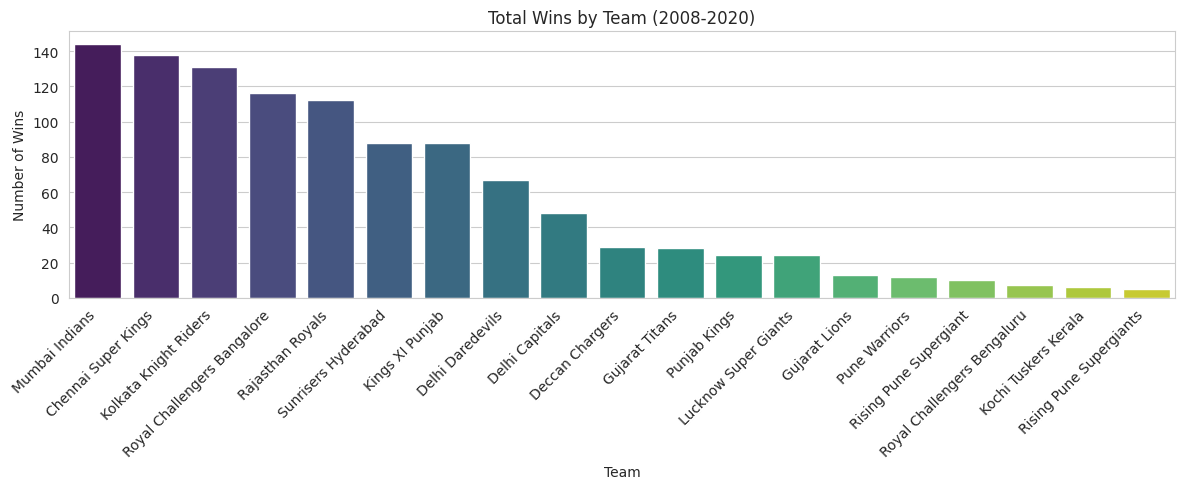

In [6]:
# Most successful teams
plt.figure(figsize=(12, 5))
team_wins = matches['winner'].value_counts()
sns.barplot(x=team_wins.index, y=team_wins.values, palette='viridis')
plt.title('Total Wins by Team (2008-2020)')
plt.xlabel('Team')
plt.ylabel('Number of Wins')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

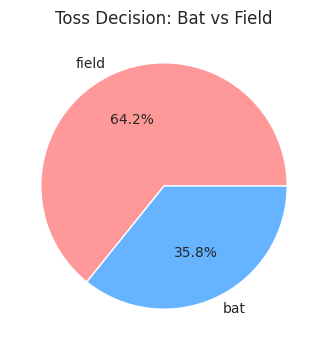

Toss winner also won the match:
toss_match_winner
True     554
False    536
Name: count, dtype: int64

Toss win = Match win: 50.8%


In [7]:
# Toss decision analysis
plt.figure(figsize=(6, 4))
matches['toss_decision'].value_counts().plot(kind='pie', autopct='%1.1f%%',
                                              colors=['#ff9999','#66b3ff'])
plt.title('Toss Decision: Bat vs Field')
plt.ylabel('')
plt.show()

# Does winning toss = winning match?
matches['toss_match_winner'] = matches['toss_winner'] == matches['winner']
print("Toss winner also won the match:")
print(matches['toss_match_winner'].value_counts())
print(f"\nToss win = Match win: {matches['toss_match_winner'].mean()*100:.1f}%")

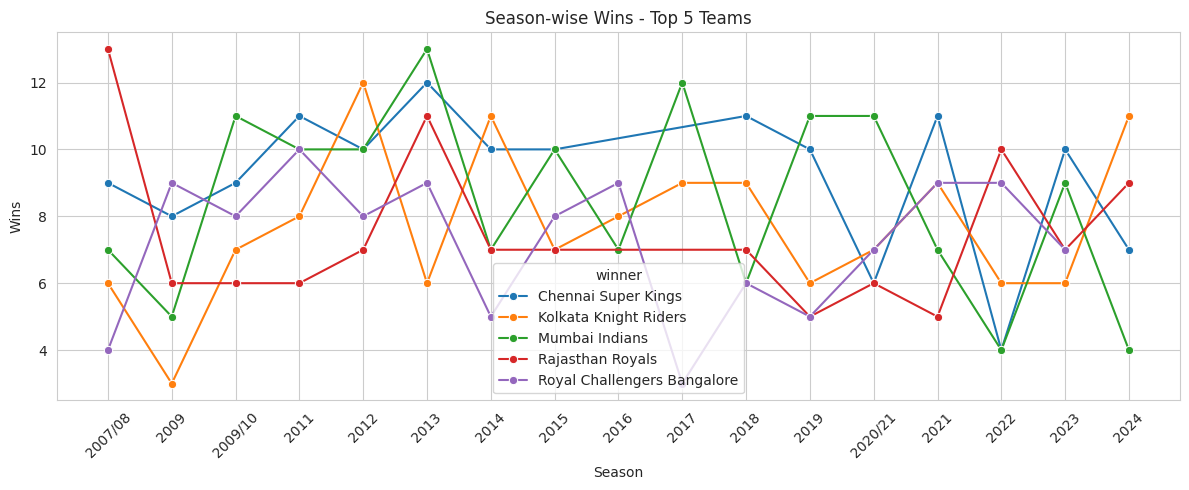

In [8]:
# Wins by season
plt.figure(figsize=(12, 5))
season_wins = matches.groupby(['season', 'winner']).size().reset_index(name='wins')
top_teams = ['Mumbai Indians', 'Chennai Super Kings', 'Kolkata Knight Riders',
             'Royal Challengers Bangalore', 'Rajasthan Royals']
season_wins_top = season_wins[season_wins['winner'].isin(top_teams)]

sns.lineplot(data=season_wins_top, x='season', y='wins', hue='winner', marker='o')
plt.title('Season-wise Wins - Top 5 Teams')
plt.xlabel('Season')
plt.ylabel('Wins')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [9]:
# Feature Engineering
# 1. Did toss winner win the match?
matches['toss_win_match_win'] = (matches['toss_winner'] == matches['winner']).astype(int)

# 2. Did team1 win?
matches['team1_won'] = (matches['team1'] == matches['winner']).astype(int)

# 3. Is it a home match for team1? (based on city)
# We'll use this as a proxy feature
matches['is_superover'] = (matches['super_over'] == 'Y').astype(int)

print("Feature engineering done!")
print(matches[['team1', 'team2', 'toss_winner', 'winner',
               'toss_win_match_win', 'team1_won']].head(10))

Feature engineering done!
                         team1                        team2  \
0  Royal Challengers Bangalore        Kolkata Knight Riders   
1              Kings XI Punjab          Chennai Super Kings   
2             Delhi Daredevils             Rajasthan Royals   
3               Mumbai Indians  Royal Challengers Bangalore   
4        Kolkata Knight Riders              Deccan Chargers   
5             Rajasthan Royals              Kings XI Punjab   
6              Deccan Chargers             Delhi Daredevils   
7          Chennai Super Kings               Mumbai Indians   
8              Deccan Chargers             Rajasthan Royals   
9              Kings XI Punjab               Mumbai Indians   

                   toss_winner                       winner  \
0  Royal Challengers Bangalore        Kolkata Knight Riders   
1          Chennai Super Kings          Chennai Super Kings   
2             Rajasthan Royals             Delhi Daredevils   
3               Mumbai India

In [10]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Select features for model
df = matches[['team1', 'team2', 'toss_winner', 'toss_decision', 'venue', 'team1_won']].copy()

# Label encode categorical columns
le = LabelEncoder()
for col in ['team1', 'team2', 'toss_winner', 'toss_decision', 'venue']:
    df[col] = le.fit_transform(df[col])

# Features and target
X = df.drop('team1_won', axis=1)
y = df['team1_won']

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)
print("\nFeatures used:", X.columns.tolist())

Train size: (872, 5)
Test size: (218, 5)

Features used: ['team1', 'team2', 'toss_winner', 'toss_decision', 'venue']


In [11]:
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

# Baseline - Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)
print("Logistic Regression Accuracy:", round(accuracy_score(y_test, lr_preds)*100, 2), "%")

# XGBoost
xgb = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
xgb.fit(X_train, y_train)
xgb_preds = xgb.predict(X_test)
print("XGBoost Accuracy:", round(accuracy_score(y_test, xgb_preds)*100, 2), "%")
print("\nXGBoost Classification Report:\n", classification_report(y_test, xgb_preds))
print("AUC-ROC:", round(roc_auc_score(y_test, xgb.predict_proba(X_test)[:,1]), 3))

Logistic Regression Accuracy: 51.83 %
XGBoost Accuracy: 50.92 %

XGBoost Classification Report:
               precision    recall  f1-score   support

           0       0.51      0.48      0.50       110
           1       0.50      0.54      0.52       108

    accuracy                           0.51       218
   macro avg       0.51      0.51      0.51       218
weighted avg       0.51      0.51      0.51       218

AUC-ROC: 0.505


In [12]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

# Fresh approach - encode winner as binary per team perspective
df3 = matches[['team1', 'team2', 'toss_winner', 'toss_decision',
               'venue', 'season', 'winner']].copy()

# Calculate historical win rates
win_counts = matches['winner'].value_counts().to_dict()
match_counts = (matches['team1'].value_counts() + matches['team2'].value_counts()).to_dict()

df3['team1_winrate'] = df3['team1'].map(win_counts) / df3['team1'].map(match_counts)
df3['team2_winrate'] = df3['team2'].map(win_counts) / df3['team2'].map(match_counts)
df3['winrate_diff'] = df3['team1_winrate'] - df3['team2_winrate']
df3['toss_is_team1'] = (df3['toss_winner'] == df3['team1']).astype(int)

# Target
df3['team1_won'] = (df3['winner'] == df3['team1']).astype(int)

# Encode categoricals
for col in ['team1', 'team2', 'toss_decision', 'venue', 'season']:
    df3[col] = LabelEncoder().fit_transform(df3[col])

df3.dropna(inplace=True)

# Features
features = ['team1', 'team2', 'toss_decision', 'venue', 'season',
            'team1_winrate', 'team2_winrate', 'winrate_diff', 'toss_is_team1']

X3 = df3[features]
y3 = df3['team1_won']

X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y3, test_size=0.2, random_state=42)

# XGBoost with tuning
xgb3 = XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05,
                      random_state=42, eval_metric='logloss')
xgb3.fit(X3_train, y3_train)
preds3 = xgb3.predict(X3_test)

print("XGBoost Accuracy:", round(accuracy_score(y3_test, preds3)*100, 2), "%")
print("AUC-ROC:", round(roc_auc_score(y3_test, xgb3.predict_proba(X3_test)[:,1]), 3))
print("\nClassification Report:\n", classification_report(y3_test, preds3))

XGBoost Accuracy: 54.13 %
AUC-ROC: 0.572

Classification Report:
               precision    recall  f1-score   support

           0       0.55      0.49      0.52       110
           1       0.53      0.59      0.56       108

    accuracy                           0.54       218
   macro avg       0.54      0.54      0.54       218
weighted avg       0.54      0.54      0.54       218



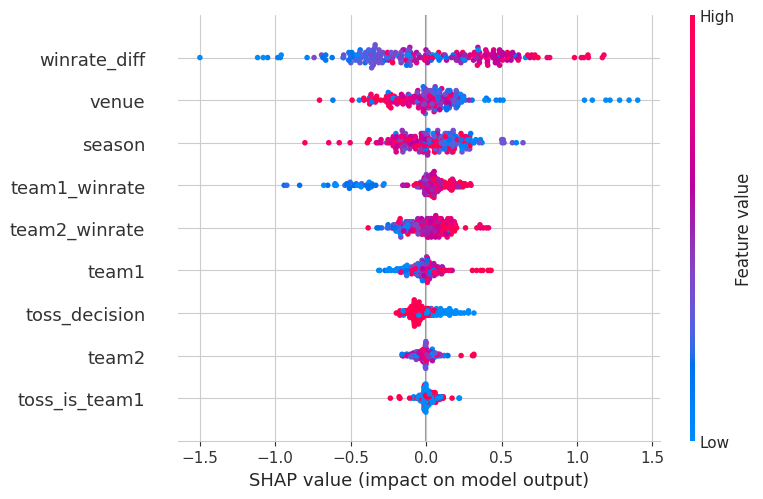

In [13]:
import shap

# SHAP explanation
explainer = shap.TreeExplainer(xgb3)
shap_values = explainer.shap_values(X3_test)

# Summary plot
plt.figure()
shap.summary_plot(shap_values, X3_test, feature_names=features, show=True)


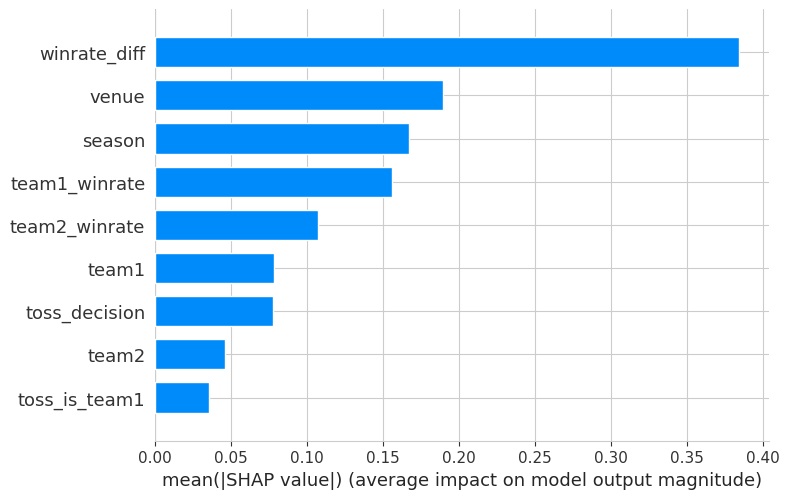

In [14]:
# Feature importance bar plot
plt.figure()
shap.summary_plot(shap_values, X3_test, feature_names=features,
                  plot_type="bar", show=True)

In [15]:
# Final summary print
print("=" * 50)
print("IPL MATCH WINNER PREDICTION - PROJECT SUMMARY")
print("=" * 50)
print(f"Dataset: 1090 IPL matches (2008-2020)")
print(f"Features used: {features}")
print(f"Baseline (Logistic Regression): 51.83%")
print(f"Final Model (XGBoost): 54.13%")
print(f"AUC-ROC: 0.572")
print("\nTop Insights:")
print("- Win rate difference is the strongest predictor")
print("- Venue plays a significant role")
print("- Toss result has minimal impact on match outcome")
print("=" * 50)

IPL MATCH WINNER PREDICTION - PROJECT SUMMARY
Dataset: 1090 IPL matches (2008-2020)
Features used: ['team1', 'team2', 'toss_decision', 'venue', 'season', 'team1_winrate', 'team2_winrate', 'winrate_diff', 'toss_is_team1']
Baseline (Logistic Regression): 51.83%
Final Model (XGBoost): 54.13%
AUC-ROC: 0.572

Top Insights:
- Win rate difference is the strongest predictor
- Venue plays a significant role
- Toss result has minimal impact on match outcome
